# Segmentacion no supervisada de pacientes

Este notebook usa K-Means para encontrar **perfiles exploratorios** de pacientes por similitud de variables clinicas. Los clusters no se nombran como enfermedades ni se interpretan como diagnosticos. Las tasas de positivos y probabilidades supervisadas se guardan solo como **referencia descriptiva posterior**, no como criterio para crear el cluster.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [2]:
models_dir = Path("models") if Path("models").exists() else Path("../models")

diabetes_bundle = joblib.load(models_dir / "diabetes_model.joblib")
paro_bundle     = joblib.load(models_dir / "paro_cardiaco_model.joblib")
hiper_bundle    = joblib.load(models_dir / "hipertension_model.joblib")

print("Modelos supervisados cargados:")
print(" - diabetes      :", type(diabetes_bundle["model"]).__name__)
print(" - paro_cardiaco :", type(paro_bundle["model"]).__name__)
print(" - hipertension  :", type(hiper_bundle["model"]).__name__)


Modelos supervisados cargados:
 - diabetes      : RandomForestClassifier
 - paro_cardiaco : LogisticRegression
 - hipertension  : CalibratedClassifierCV


In [3]:
def find_optimal_k(X_scaled, k_range=range(2, 7)):
    scores = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
        labels = km.fit_predict(X_scaled)
        scores[k] = silhouette_score(X_scaled, labels)
    return scores


def describe_cluster_profile(raw_features, labels, top_features=6):
    global_mean = raw_features.mean()
    global_std = raw_features.std(ddof=0).replace(0, 1)
    cluster_means = raw_features.assign(cluster=labels).groupby("cluster")[raw_features.columns].mean()
    z_means = (cluster_means - global_mean) / global_std

    descriptors = {}
    for cluster_id, row in z_means.iterrows():
        strongest = row.abs().sort_values(ascending=False).head(top_features).index
        descriptors[int(cluster_id)] = [
            {
                "feature": feature,
                "direction": "alto" if row[feature] > 0 else "bajo",
                "z_score": float(row[feature]),
                "mean": float(cluster_means.loc[cluster_id, feature]),
            }
            for feature in strongest
        ]
    return cluster_means, z_means, descriptors


def cluster_and_profile(name, raw_features, y_truth=None, y_proba=None, top_features=8):
    raw_features = raw_features.select_dtypes(include=np.number).copy()

    scaler = StandardScaler()
    X_s = scaler.fit_transform(raw_features)

    scores = find_optimal_k(X_s)
    k = max(scores, key=scores.get)
    print(f"\n=== {name} ===")
    print(f"Silhouette por k: {{ {', '.join(f'{kk}:{vv:.3f}' for kk,vv in scores.items())} }}")
    print(f"k seleccionado = {k}")

    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_s)

    prof = raw_features.copy()
    prof["cluster"] = labels

    summary = prof.groupby("cluster").agg(n=("cluster", "size"))
    summary["pct_muestra"] = summary["n"] / len(prof)

    if y_truth is not None:
        summary["tasa_positivos_referencia"] = pd.Series(y_truth.values, index=prof.index).groupby(labels).mean().values
    else:
        summary["tasa_positivos_referencia"] = np.nan

    if y_proba is not None:
        summary["proba_media_supervisado_referencia"] = pd.Series(y_proba, index=prof.index).groupby(labels).mean().values
    else:
        summary["proba_media_supervisado_referencia"] = np.nan

    summary = summary.round(4)
    print("\nResumen descriptivo por perfil:")
    display(summary)

    cluster_means, z_means, descriptors = describe_cluster_profile(raw_features, labels, top_features=top_features)
    top = z_means.abs().mean(axis=0).sort_values(ascending=False).head(top_features).index.tolist()
    print(f"\nVariables que mas separan perfiles ({top_features}):")
    display(cluster_means[top].round(2))

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_s)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=labels, palette="tab10", s=22, alpha=0.7, ax=axes[0], legend="full")
    axes[0].set_title(f"{name} - perfiles K-Means (PCA)")
    axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
    axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")

    summary[["pct_muestra"]].plot(kind="bar", ax=axes[1], color="#4C9AFF")
    axes[1].set_title(f"{name} - tamano relativo de perfiles")
    axes[1].set_ylabel("proporcion de la muestra")
    axes[1].set_ylim(0, max(0.1, float(summary["pct_muestra"].max()) * 1.2))
    plt.tight_layout(); plt.show()

    return {
        "kmeans": km,
        "scaler": scaler,
        "k": int(k),
        "silhouette": float(scores[k]),
        "summary": summary,
        "cluster_means_top": cluster_means[top],
        "descriptors": descriptors,
    }

Cargado: ../Base-de-datos/raw/diabetes.csv  shape=(768, 9)
Dataset limpio guardado en: ..\Base-de-datos\cleaned\diabetes_cleaned.csv


C:\Users\mafig\anaconda3\envs\mineriadedatos\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\mafig\anaconda3\envs\mineriadedatos\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")



=== Diabetes ===
Silhouette por k: { 2:0.196, 3:0.195, 4:0.185, 5:0.182, 6:0.168 }
k seleccionado = 2

Resumen descriptivo por perfil:


,n,pct_muestra,tasa_positivos_referencia,proba_media_supervisado_referencia
cluster,,,,
0,353,0.4596,0.5524,0.5273
1,415,0.5404,0.1759,0.1892



Variables que mas separan perfiles (8):


,Age,Pregnancies,BloodPressure,Glucose,SkinThickness,BMI,Insulin,DiabetesPedigreeFunction
cluster,,,,,,,,
0,41.03,5.76,78.90,137.84,32.73,35.28,168.70,0.50
1,26.62,2.22,66.84,107.89,26.03,30.05,116.83,0.44


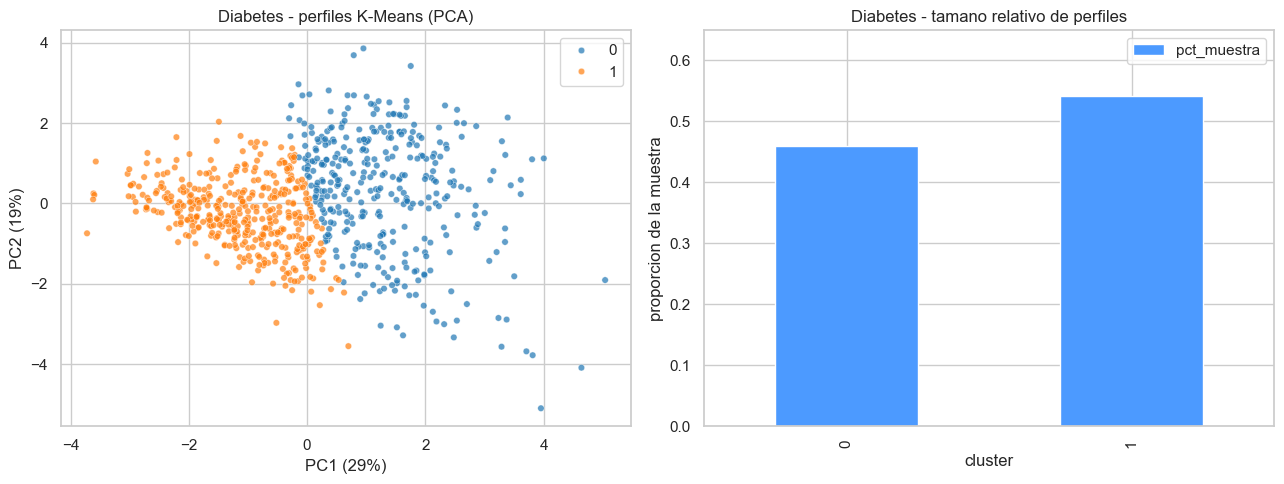

In [4]:
paths = ["Base-de-datos/raw/diabetes.csv", "../Base-de-datos/raw/diabetes.csv"]
csv = next((p for p in paths if Path(p).exists()), None)
assert csv, "No encontré diabetes.csv"
df_d = pd.read_csv(csv)
print(f"Cargado: {csv}  shape={df_d.shape}")

# limpieza igual que el supervisado
for c in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    df_d[c] = df_d[c].replace(0, np.nan)
df_d = df_d.fillna(df_d.median(numeric_only=True))

cleaned_dir = Path(csv).parent.parent / "cleaned"
cleaned_dir.mkdir(parents=True, exist_ok=True)
cleaned_path = cleaned_dir / "diabetes_cleaned.csv"
df_d.to_csv(cleaned_path, index=False)
print(f"Dataset limpio guardado en: {cleaned_path}")

raw_d   = df_d.drop(columns=["Outcome"])
y_truth = df_d["Outcome"].astype(int)

# recrear binning + one-hot para alimentar el modelo supervisado
df_eng = df_d.copy()
df_eng["BMI_Category"]      = pd.cut(df_eng["BMI"],            bins=[0,18.5,25,30,100],   labels=["Underweight","Normal","Overweight","Obese"])
df_eng["AgeGroup"]          = pd.cut(df_eng["Age"],            bins=[0,30,45,60,120],     labels=["Young","Adult","Middle-aged","Senior"])
df_eng["Glucose_Category"]  = pd.cut(df_eng["Glucose"],        bins=[0,99,125,300],       labels=["Normal","Prediabetes","Diabetes"])
df_eng["Insulin_Category"]  = pd.cut(df_eng["Insulin"],        bins=[0,16,166,1000],      labels=["Low","Normal","High"])
df_eng["BP_Category"]       = pd.cut(df_eng["BloodPressure"],  bins=[0,80,89,200],        labels=["Normal","Elevated","High"])
df_eng = pd.get_dummies(df_eng, columns=["BMI_Category","AgeGroup","Glucose_Category","Insulin_Category","BP_Category"])

expected = diabetes_bundle["metadata"]["feature_columns"]
for c in expected:
    if c not in df_eng.columns:
        df_eng[c] = 0
y_proba = diabetes_bundle["model"].predict_proba(df_eng[expected])[:, 1]

result_d = cluster_and_profile("Diabetes", raw_d, y_truth, y_proba)


Cargado: ../Base-de-datos/raw/Medicaldataset.csv  shape=(1319, 9)
Dataset limpio guardado en: ..\Base-de-datos\cleaned\Medicaldataset_cleaned.csv


C:\Users\mafig\anaconda3\envs\mineriadedatos\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



=== Paro cardíaco ===
Silhouette por k: { 2:0.170, 3:0.167, 4:0.225, 5:0.214, 6:0.225 }
k seleccionado = 6

Resumen descriptivo por perfil:


,n,pct_muestra,tasa_positivos_referencia,proba_media_supervisado_referencia
cluster,,,,
0,397,0.3010,0.5340,0.5358
1,513,0.3889,0.6394,0.6339
2,39,0.0296,1.0000,1.0000
3,3,0.0023,0.6667,0.9286
4,22,0.0167,0.9545,1.0000
5,345,0.2616,0.6029,0.5891



Variables que mas separan perfiles (8):


,Heart rate,Troponin,CK-MB,Gender,Diastolic blood pressure,Systolic blood pressure,Age,Blood sugar
cluster,,,,,,,,
0,75.47,0.15,8.37,0.00,70.46,122.64,58.79,143.41
1,75.89,0.24,8.04,1.00,64.35,112.54,55.08,148.51
2,75.31,0.36,258.94,0.72,71.87,127.28,56.49,172.13
3,1111.00,0.35,2.62,0.33,95.00,141.00,49.00,109.67
4,81.32,7.70,5.45,0.68,72.95,132.18,61.23,147.95
5,76.45,0.32,7.17,0.91,85.93,153.69,54.57,144.91


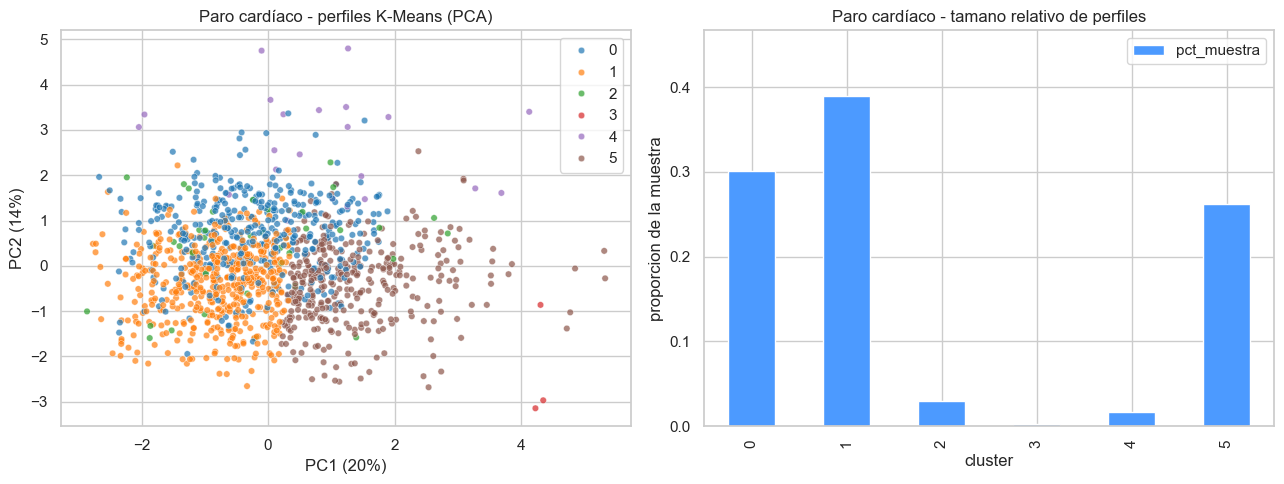

In [5]:
paths = ["Base-de-datos/raw/Medicaldataset.csv", "../Base-de-datos/raw/Medicaldataset.csv"]
csv = next((p for p in paths if Path(p).exists()), None)
assert csv, "No encontré Medicaldataset.csv"
df_p = pd.read_csv(csv)
print(f"Cargado: {csv}  shape={df_p.shape}")

df_p["Result"] = (df_p["Result"].astype(str).str.strip().str.lower()
                  .map({"negative": 0, "positive": 1}).astype(int))

cleaned_dir = Path(csv).parent.parent / "cleaned"
cleaned_dir.mkdir(parents=True, exist_ok=True)
cleaned_path = cleaned_dir / "Medicaldataset_cleaned.csv"
df_p.to_csv(cleaned_path, index=False)
print(f"Dataset limpio guardado en: {cleaned_path}")

raw_p   = df_p.drop(columns=["Result"])
y_truth = df_p["Result"]

X_scaled = paro_bundle["scaler"].transform(raw_p)
y_proba  = paro_bundle["model"].predict_proba(X_scaled)[:, 1]

result_p = cluster_and_profile("Paro cardíaco", raw_p, y_truth, y_proba)


Cargado: ../Base-de-datos/raw/Hipertension_Arterial_Mexico.csv  shape=(4363, 36)
Dataset limpio guardado en: ..\Base-de-datos\cleaned\Hipertension_Arterial_Mexico_cleaned.csv



=== Hipertensión ===
Silhouette por k: { 2:0.289, 3:0.294, 4:0.299, 5:0.291, 6:0.301 }
k seleccionado = 6

Resumen descriptivo por perfil:


,n,pct_muestra,tasa_positivos_referencia,proba_media_supervisado_referencia
cluster,,,,
0,118,0.0270,0.7627,0.7775
1,442,0.1013,0.7715,0.7448
2,477,0.1093,0.2117,0.2123
3,429,0.0983,0.1702,0.1944
4,2592,0.5941,0.7523,0.7493
5,305,0.0699,0.8557,0.8495



Variables que mas separan perfiles (8):


,valor_hemoglobina_glucosilada,resultado_glucosa_promedio,segundamedicion_cintura,peso,masa_corporal,medida_cintura,edad,resultado_glucosa
cluster,,,,,,,,
0,10.68,268.16,31.04,47.19,20.04,63.54,54.26,255.97
1,5.30,105.45,0.21,71.85,28.90,82.71,36.17,88.94
2,5.39,108.39,76.78,2.55,2.41,0.54,65.20,93.30
3,5.46,110.28,105.42,2.00,1.00,0.00,65.39,94.46
4,5.23,103.95,0.00,74.10,28.12,87.24,42.73,91.81
5,5.59,113.49,5.23,74.96,27.33,92.13,46.39,99.10


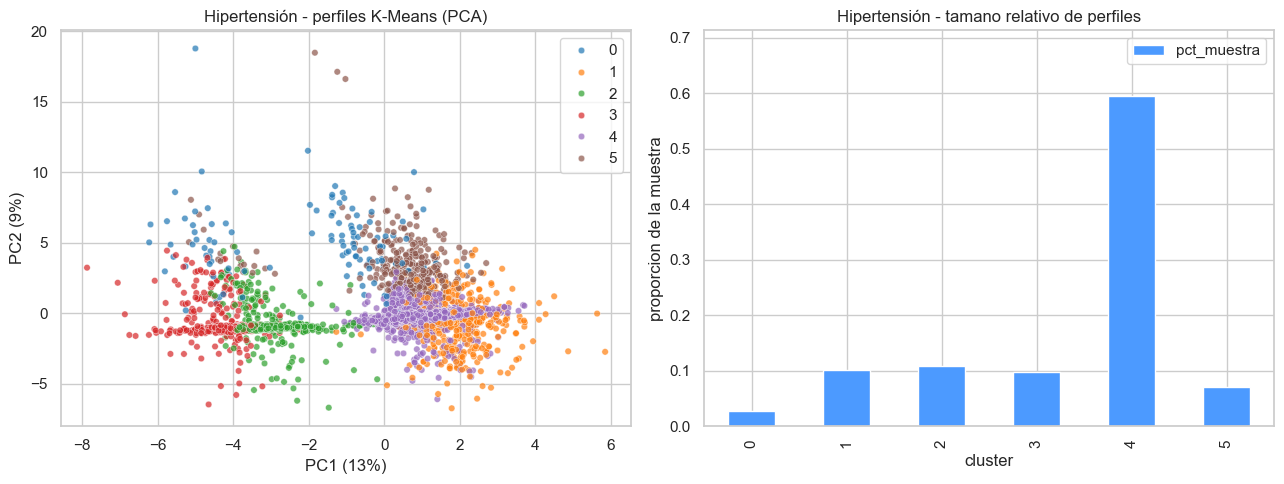

In [6]:
paths = ["Base-de-datos/raw/Hipertension_Arterial_Mexico.csv", "../Base-de-datos/raw/Hipertension_Arterial_Mexico.csv"]
csv = next((p for p in paths if Path(p).exists()), None)
assert csv, "No encontré Hipertension_Arterial_Mexico.csv"
df_h = pd.read_csv(csv)
print(f"Cargado: {csv}  shape={df_h.shape}")

# misma limpieza que el supervisado (incluye FOLIO_I)
id_like = [c for c in df_h.columns if c.lower() in {"id","id_paciente","paciente_id","folio","folio_i"}]
df_h = df_h.drop(columns=id_like)
if "sexo" in df_h.columns and df_h["sexo"].dtype == object:
    mp = {v: i for i, v in enumerate(sorted(df_h["sexo"].dropna().unique()))}
    df_h["sexo"] = df_h["sexo"].map(mp)
df_h = df_h.fillna(df_h.median(numeric_only=True))

cleaned_dir = Path(csv).parent.parent / "cleaned"
cleaned_dir.mkdir(parents=True, exist_ok=True)
cleaned_path = cleaned_dir / "Hipertension_Arterial_Mexico_cleaned.csv"
df_h.to_csv(cleaned_path, index=False)
print(f"Dataset limpio guardado en: {cleaned_path}")

raw_h   = df_h.drop(columns=["riesgo_hipertension"])
y_truth = df_h["riesgo_hipertension"].astype(int)

expected = hiper_bundle["metadata"]["feature_columns"]
X_aligned = raw_h[expected]
X_scaled  = hiper_bundle["scaler"].transform(X_aligned)
y_proba   = hiper_bundle["model"].predict_proba(X_scaled)[:, 1]
upper_bound = hiper_bundle["metadata"].get("probability_upper_bound")
if upper_bound is not None:
    y_proba = np.minimum(y_proba, float(upper_bound))

result_h = cluster_and_profile("Hipertensión", raw_h, y_truth, y_proba)

=== Resumen global de perfiles exploratorios ===


n  pct_muestra  tasa_positivos_referencia  \
enfermedad    cluster                                                 
diabetes      0         353       0.4596                     0.5524   
              1         415       0.5404                     0.1759   
paro_cardiaco 0         397       0.3010                     0.5340   
              1         513       0.3889                     0.6394   
              2          39       0.0296                     1.0000   
              3           3       0.0023                     0.6667   
              4          22       0.0167                     0.9545   
              5         345       0.2616                     0.6029   
hipertension  0         118       0.0270                     0.7627   
              1         442       0.1013                     0.7715   
              2         477       0.1093                     0.2117   
              3         429       0.0983                     0.1702   
              4        2592       0.5941                     0.7523   
              5         305       0.0699                     0.8557   

                       proba_media_supervisado_referencia  
enfermedad    cluster                                      
diabetes      0                                    0.5273  
              1                                    0.1892  
paro_cardiaco 0                                    0.5358  
              1                                    0.6339  
              2                                    1.0000  
              3                                    0.9286  
              4                                    1.0000  
              5                                    0.5891  
hipertension  0                                    0.7775  
              1                                    0.7448  
              2                                    0.2123  
              3                                    0.1944  
              4                                    0.7493  
              5                                    0.8495

C:\Users\mafig\AppData\Local\Temp\ipykernel_26824\301100884.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["label"], rotation=45, ha="right")


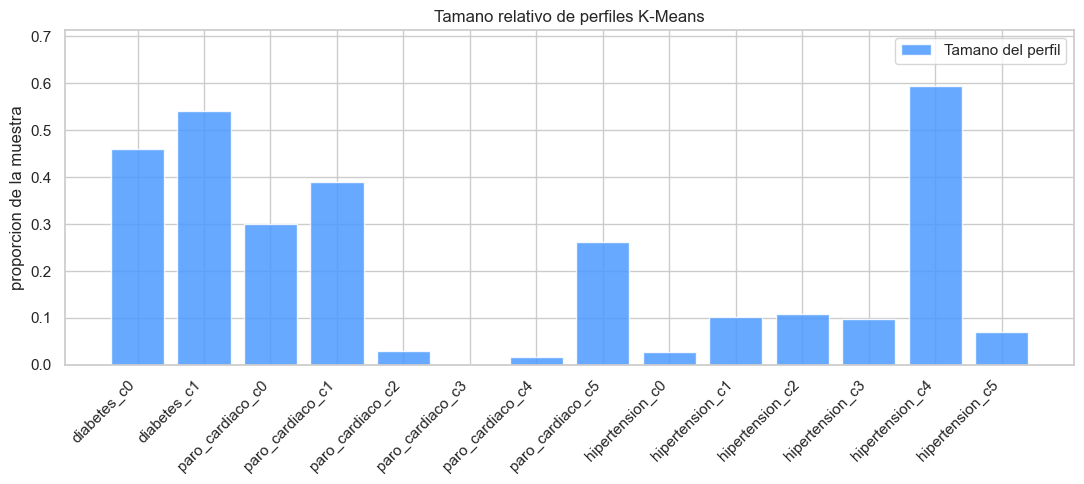

In [7]:
all_summaries = {
    "diabetes": result_d["summary"],
    "paro_cardiaco": result_p["summary"],
    "hipertension": result_h["summary"],
}
combined = pd.concat(all_summaries, names=["enfermedad", "cluster"])
print("=== Resumen global de perfiles exploratorios ===")
display(combined)

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = combined.reset_index()
plot_df["label"] = plot_df["enfermedad"] + "_c" + plot_df["cluster"].astype(str)
ax.bar(plot_df["label"], plot_df["pct_muestra"], color="#4C9AFF", alpha=0.85, label="Tamano del perfil")
ax.set_xticklabels(plot_df["label"], rotation=45, ha="right")
ax.set_ylim(0, max(0.1, float(plot_df["pct_muestra"].max()) * 1.2))
ax.set_ylabel("proporcion de la muestra")
ax.set_title("Tamano relativo de perfiles K-Means")
ax.legend()
plt.tight_layout(); plt.show()

In [8]:
artifact = {
    "diabetes": {"kmeans": result_d["kmeans"], "scaler": result_d["scaler"], "k": result_d["k"], "silhouette": result_d["silhouette"]},
    "paro_cardiaco": {"kmeans": result_p["kmeans"], "scaler": result_p["scaler"], "k": result_p["k"], "silhouette": result_p["silhouette"]},
    "hipertension": {"kmeans": result_h["kmeans"], "scaler": result_h["scaler"], "k": result_h["k"], "silhouette": result_h["silhouette"]},
}
joblib.dump(artifact, models_dir / "subtipos_kmeans.joblib")

metadata = {
    "approach": "KMeans exploratorio por dataset; k elegido por silhouette en [2,6]. Las etiquetas y probabilidades se usan solo como referencia descriptiva posterior, no para definir ni diagnosticar clusters.",
    "interpretation_warning": "Un cluster indica similitud estadistica entre pacientes, no presencia ni ausencia de una enfermedad.",
    "datasets": {
        "diabetes": {"k": result_d["k"], "silhouette": result_d["silhouette"]},
        "paro_cardiaco": {"k": result_p["k"], "silhouette": result_p["silhouette"]},
        "hipertension": {"k": result_h["k"], "silhouette": result_h["silhouette"]},
    },
    "summary_per_cluster": {
        name: r["summary"].reset_index().to_dict(orient="records")
        for name, r in [("diabetes", result_d), ("paro_cardiaco", result_p), ("hipertension", result_h)]
    },
    "profile_descriptors": {
        name: r["descriptors"]
        for name, r in [("diabetes", result_d), ("paro_cardiaco", result_p), ("hipertension", result_h)]
    },
}
with open(models_dir / "subtipos_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False, default=str)

combined.to_csv(models_dir / "subtipos_summary.csv")
print("Guardado:")
print(" -", models_dir / "subtipos_kmeans.joblib")
print(" -", models_dir / "subtipos_metadata.json")
print(" -", models_dir / "subtipos_summary.csv")

Guardado:
 - ..\models\subtipos_kmeans.joblib
 - ..\models\subtipos_metadata.json
 - ..\models\subtipos_summary.csv


## Conclusion

K-Means encontro perfiles exploratorios de pacientes por similitud de variables. Estos perfiles no significan que el paciente tenga una enfermedad especifica ni deben usarse como diagnostico.

La tasa de positivos y la probabilidad supervisada se guardan solo como referencia descriptiva posterior para comparar contra los modelos supervisados.

Artefactos en `models/`: `subtipos_kmeans.joblib` (modelos K-Means + scalers), `subtipos_metadata.json`, `subtipos_summary.csv`.